# HCP Young Adult dataset analysis

## Dataset and project initialization

In [199]:
!uv sync

Resolved 46 packages in 19ms
Audited 41 packages in 26ms


In [223]:
import glob, numpy as np, nibabel as nib, collections
import matplotlib.pyplot as plt
from pathlib import Path
from nibabel.cifti2.cifti2 import Cifti2Image
from scipy.signal import welch
from nilearn import plotting, image

In [201]:
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
files = sorted(ROOT.glob("data/*/MNINonLinear/Results/tfMRI_*_??/*dtseries.nii"))

In [ ]:
runs, meta = [], []
for f in files:
    subject, task, enc = f.parts[-5], *f.parts[-2].split("_")[1:3]
    img = Cifti2Image.from_filename(f)      # prima i str i Path
    x = img.get_fdata(dtype=np.float32)
    axis = img.header.get_axis(1)                   # (T, 91282)
    runs.append(np.column_stack([x[:, labels == i].mean(1) for i in range(len(names))]))
    meta.append((subject, task, enc))
    print(len(runs), subject, task, enc, runs[-1].shape)

1 111211 EMOTION LR (176, 21)
2 111211 EMOTION RL (176, 21)
3 111211 GAMBLING LR (253, 21)
4 111211 GAMBLING RL (253, 21)
5 111211 LANGUAGE LR (316, 21)
6 111211 LANGUAGE RL (316, 21)
7 111211 MOTOR LR (284, 21)
8 111211 MOTOR RL (284, 21)
9 111211 RELATIONAL LR (232, 21)
10 111211 RELATIONAL RL (232, 21)
11 111211 SOCIAL LR (274, 21)
12 111211 SOCIAL RL (274, 21)
13 111211 WM LR (405, 21)
14 111211 WM RL (405, 21)
15 135124 EMOTION LR (176, 21)
16 135124 EMOTION RL (176, 21)
17 135124 GAMBLING LR (253, 21)
18 135124 GAMBLING RL (253, 21)
19 135124 LANGUAGE LR (316, 21)
20 135124 LANGUAGE RL (316, 21)
21 135124 MOTOR LR (284, 21)
22 135124 MOTOR RL (284, 21)
23 135124 RELATIONAL LR (232, 21)
24 135124 RELATIONAL RL (232, 21)
25 135124 SOCIAL LR (274, 21)
26 135124 SOCIAL RL (274, 21)
27 135124 WM LR (405, 21)
28 135124 WM RL (405, 21)
29 153126 EMOTION LR (176, 21)
30 153126 EMOTION RL (176, 21)
31 153126 GAMBLING LR (253, 21)
32 153126 GAMBLING RL (253, 21)
33 153126 LANGUAGE LR (316,

KeyboardInterrupt: 

In [207]:
DESIKAN = ["bankssts", "caudalanteriorcingulate", "caudalmiddlefrontal", None, "cuneus",
           "entorhinal", "fusiform", "inferiorparietal", "inferiortemporal",
           "isthmuscingulate", "lateraloccipital", "lateralorbitofrontal", "lingual",
           "medialorbitofrontal", "middletemporal", "parahippocampal", "paracentral",
           "parsopercularis", "parsorbitalis", "parstriangularis", "pericalcarine",
           "postcentral", "posteriorcingulate", "precentral", "precuneus",
           "rostralanteriorcingulate", "rostralmiddlefrontal", "superiorfrontal",
           "superiorparietal", "superiortemporal", "supramarginal", "frontalpole",
           "temporalpole", "transversetemporal", "insula"]      # None = corpus callosum

CODES = {c: f"{h}_{nm}" for k, nm in enumerate(DESIKAN) if nm
         for c, h in ((1001 + k, "L"), (2001 + k, "R"))}
CODES.update({8: "L_cerebellum", 10: "L_thalamus", 11: "L_caudate", 12: "L_putamen",
              13: "L_pallidum", 17: "L_hippocampus", 18: "L_amygdala", 26: "L_accumbens",
              28: "L_ventralDC", 47: "R_cerebellum", 49: "R_thalamus", 50: "R_caudate",
              51: "R_putamen", 52: "R_pallidum", 53: "R_hippocampus", 54: "R_amygdala",
              58: "R_accumbens", 60: "R_ventralDC", 16: "brainstem"})

CODE_LIST = sorted(CODES)
names = [CODES[c] for c in CODE_LIST]
R = len(CODE_LIST)
print(R, "regiona:", names[:3], "...", names[-3:])

87 regiona: ['L_cerebellum', 'L_thalamus', 'L_caudate'] ... ['R_temporalpole', 'R_transversetemporal', 'R_insula']


In [208]:
vol_files = sorted(ROOT.glob(
    "data/*/MNINonLinear/Results/tfMRI_*_??/*_hp0_clean_rclean_tclean.nii.gz"))
print(len(vol_files), "runova")
print(vol_files[0].parts[-5], vol_files[0].parts[-2])

139 runova
111211 tfMRI_EMOTION_LR


In [209]:
runs, meta, current = [], [], None

for f in vol_files:
    subject, task, enc = f.parts[-5], *f.parts[-2].split("_")[1:3]

    if subject != current:                          # parcelacija je po ispitaniku
        w = nib.load(str(ROOT / "data" / subject / "MNINonLinear/ROIs/wmparc.2.nii.gz"))
        codes = w.get_fdata().astype(np.int32).ravel()
        lab = np.zeros(codes.shape, dtype=np.int32)
        for i, c in enumerate(CODE_LIST, start=1):
            lab[codes == c] = i
        vox, lab_v = np.flatnonzero(lab), None
        lab_v = lab[vox]
        counts = np.bincount(lab_v, minlength=R + 1)[1:]
        current = subject

    img = nib.load(str(f))
    nt  = img.shape[3]
    x   = img.get_fdata(dtype=np.float32).reshape(-1, nt)[vox]
    runs.append(np.stack([np.bincount(lab_v, weights=x[:, j], minlength=R + 1)[1:] / counts
                          for j in range(nt)]).astype(np.float32))
    meta.append((subject, task, enc))
    print(f"{len(runs):3d}/{len(vol_files)}  {subject} {task}_{enc}  {runs[-1].shape}",
          flush=True)

  1/139  111211 EMOTION_LR  (176, 87)
  2/139  111211 EMOTION_RL  (176, 87)
  3/139  111211 GAMBLING_LR  (253, 87)
  4/139  111211 GAMBLING_RL  (253, 87)
  5/139  111211 LANGUAGE_LR  (316, 87)
  6/139  111211 LANGUAGE_RL  (316, 87)
  7/139  111211 MOTOR_LR  (284, 87)
  8/139  111211 MOTOR_RL  (284, 87)
  9/139  111211 RELATIONAL_LR  (232, 87)
 10/139  111211 RELATIONAL_RL  (232, 87)
 11/139  111211 SOCIAL_LR  (274, 87)
 12/139  111211 SOCIAL_RL  (274, 87)
 13/139  111211 WM_LR  (405, 87)
 14/139  111211 WM_RL  (405, 87)
 15/139  135124 EMOTION_LR  (176, 87)
 16/139  135124 EMOTION_RL  (176, 87)
 17/139  135124 GAMBLING_LR  (253, 87)
 18/139  135124 GAMBLING_RL  (253, 87)
 19/139  135124 LANGUAGE_LR  (316, 87)
 20/139  135124 LANGUAGE_RL  (316, 87)
 21/139  135124 MOTOR_LR  (284, 87)
 22/139  135124 MOTOR_RL  (284, 87)
 23/139  135124 RELATIONAL_LR  (232, 87)
 24/139  135124 RELATIONAL_RL  (232, 87)
 25/139  135124 SOCIAL_LR  (274, 87)
 26/139  135124 SOCIAL_RL  (274, 87)
 27/139  13512

## Pregled signala

In [210]:
REGIONS = names                        # 87 regiona iz parcelacije
print("regioni:")
for i in range(0, len(REGIONS), 4):
    print("   " + "  ".join(f"{j:2d} {REGIONS[j]:<26}"
                            for j in range(i, min(i + 4, len(REGIONS)))))

REGION = REGIONS.index("L_precentral")     # ili prosto: REGION = 23

regioni:
    0 L_cerebellum                 1 L_thalamus                   2 L_caudate                    3 L_putamen                 
    4 L_pallidum                   5 brainstem                    6 L_hippocampus                7 L_amygdala                
    8 L_accumbens                  9 L_ventralDC                 10 R_cerebellum                11 R_thalamus                
   12 R_caudate                   13 R_putamen                   14 R_pallidum                  15 R_hippocampus             
   16 R_amygdala                  17 R_accumbens                 18 R_ventralDC                 19 L_bankssts                
   20 L_caudalanteriorcingulate   21 L_caudalmiddlefrontal       22 L_cuneus                    23 L_entorhinal              
   24 L_fusiform                  25 L_inferiorparietal          26 L_inferiortemporal          27 L_isthmuscingulate        
   28 L_lateraloccipital          29 L_lateralorbitofrontal      30 L_lingual                   31 L_medialor

In [211]:
print(len(names), names[:6])

87 ['L_cerebellum', 'L_thalamus', 'L_caudate', 'L_putamen', 'L_pallidum', 'brainstem']


In [212]:
subjects  = np.array([m[0] for m in meta])
encodings = np.array([m[2] for m in meta])
SUBJECTS, TASKS, ENCS = sorted(set(subjects)), sorted(set(y)), sorted(set(encodings))

print("ispitanici:", {i: s for i, s in enumerate(SUBJECTS)})
print("zadaci:    ", {i: t for i, t in enumerate(TASKS)})
print("kodiranja: ", {i: e for i, e in enumerate(ENCS)})

SUBJECT = SUBJECTS[2]        # 0 111211  1 135124  2 153126  3 192237  4 206525 ...
TASK    = TASKS[2]           # 0 EMOTION  1 GAMBLING  2 LANGUAGE  3 MOTOR
ENC     = ENCS[0]            # 4 RELATIONAL  5 SOCIAL  6 WM   |   0 LR  1 RL
IA, IB  = 0, 1               # indeksi uslova, vidi ispis "uslovi"
CZ      = 27                 # presek; MNI z = (CZ - 36) * 2 mm
DELAY   = 5.0
NFRAMES, NCOLS = 12, 4
REGION_NAME = REGIONS[REGION]

ispitanici: {0: np.str_('111211'), 1: np.str_('135124'), 2: np.str_('153126'), 3: np.str_('192237'), 4: np.str_('206525'), 5: np.str_('257946'), 6: np.str_('378756'), 7: np.str_('510225'), 8: np.str_('590047'), 9: np.str_('869472')}
zadaci:     {0: np.str_('EMOTION'), 1: np.str_('GAMBLING'), 2: np.str_('LANGUAGE'), 3: np.str_('MOTOR'), 4: np.str_('RELATIONAL'), 5: np.str_('SOCIAL'), 6: np.str_('WM')}
kodiranja:  {0: np.str_('LR'), 1: np.str_('RL')}


In [213]:
ACCENT, MUTED = "#3b6fb6", "#9aa0a6"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.linewidth": 0.4, "grid.color": MUTED, "grid.alpha": 0.3,
    "axes.titlelocation": "left", "axes.titlesize": 10, "axes.labelsize": 10,
    "figure.constrained_layout.use": True,
})

In [214]:
stem = f"tfMRI_{TASK}_{ENC}"
run  = ROOT / "data" / SUBJECT / "MNINonLinear/Results" / stem

REGION       = next(i for i, n in enumerate(names) if n.endswith(REGION_NAME))
REGION_SHORT = names[REGION].replace("CIFTI_STRUCTURE_", "")
RUNS_IDX     = np.flatnonzero((subjects == SUBJECT) & (y == TASK))

img4 = nib.load(str(run / f"{stem}_hp0_clean_rclean_tclean.nii.gz"))
TR   = float(img4.header.get_zooms()[3])
nx, ny, nz, nt = img4.shape
t    = np.arange(nt) * TR

sl       = np.asarray(img4.dataobj[:, :, CZ, :], dtype=np.float32)     # (nx, ny, nt)
mean_img = nib.load(str(run / f"{stem}_mean.nii.gz")).get_fdata()[:, :, CZ]
mask     = nib.load(str(run / "brainmask_fs.2.nii.gz")).get_fdata()[:, :, CZ] > 0
FRAMES   = np.linspace(0, nt - 1, NFRAMES).astype(int)

pct = np.where(mask[..., None],                                        # % promene
               (sl - mean_img[..., None]) / np.maximum(mean_img, 1)[..., None] * 100,
               np.nan)

CONDS = sorted(p.stem for p in (run / "EVs").glob("*.txt") if p.stem != "Sync")
COND_A, COND_B = CONDS[IA], CONDS[IB]

blocks = {}
for cond in (COND_A, COND_B):
    idx = set()
    for line in open(run / "EVs" / f"{cond}.txt"):
        onset, dur, _ = map(float, line.split())
        a = int(round((onset + DELAY) / TR))
        b = int(round((onset + dur + DELAY) / TR))
        idx |= set(range(max(a, 0), min(b, nt)))
    blocks[cond] = sorted(idx)

print(f"{SUBJECT} {stem}  nt={nt}  TR={TR}  z={CZ} (MNI z={(CZ - 36) * 2:+d} mm)  {REGION_SHORT}")
print("uslovi:", {i: c for i, c in enumerate(CONDS)})
print("frejmova:", {c: len(v) for c, v in blocks.items()})

153126 tfMRI_LANGUAGE_LR  nt=316  TR=0.7200000286102295  z=27 (MNI z=-18 mm)  L_precentral
uslovi: {0: 'cue', 1: 'math', 2: 'present_math', 3: 'present_story', 4: 'question_math', 5: 'question_story', 6: 'response_math', 7: 'response_story', 8: 'story'}
frejmova: {'cue': 7, 'math': 137}


Text(0.01, 0.98, 'L_precentral — ispitanik 153126, LR')

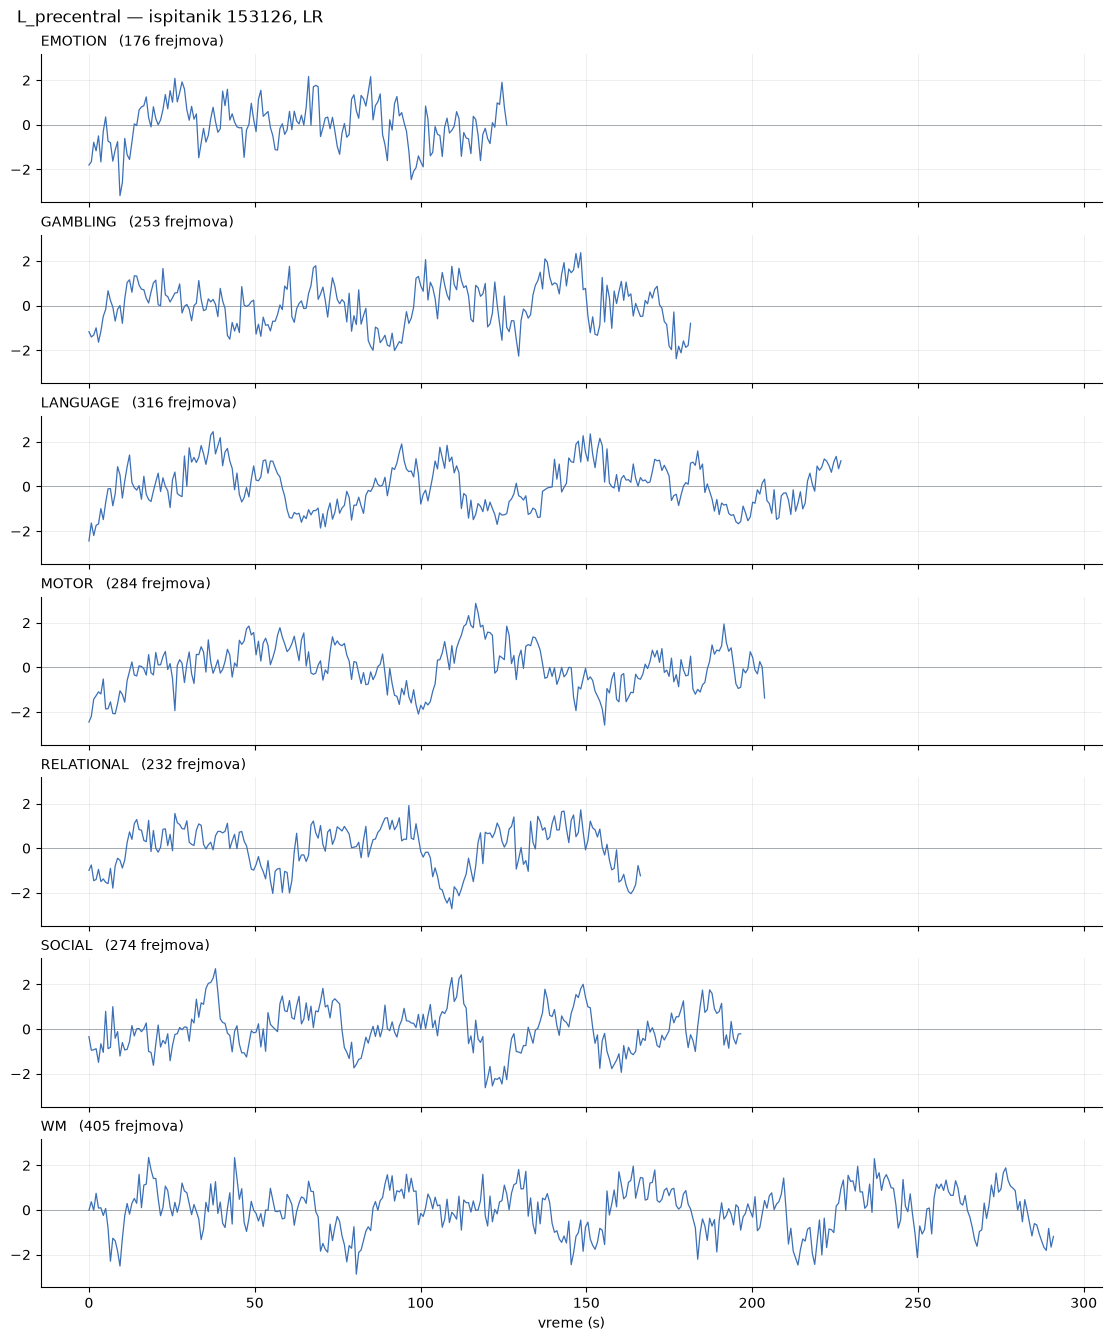

In [221]:
assert stem == f"tfMRI_{TASK}_{ENC}", "ponovo pokreni ćeliju A"

fig, axes = plt.subplots(len(TASKS), 1, figsize=(11, 1.9 * len(TASKS)),
                         sharex=True, sharey=True)
for ax, task in zip(axes, TASKS):
    i = np.flatnonzero((subjects == SUBJECT) & (y == task) & (encodings == ENC))[0]
    sig = runs[i][:, REGION]
    sig = (sig - sig.mean()) / sig.std()
    ax.plot(np.arange(len(sig)) * TR, sig, lw=0.9, color=ACCENT)
    ax.set_title(f"{task}   ({len(sig)} frejmova)")
    ax.axhline(0, lw=0.6, color=MUTED, zorder=0)
axes[-1].set_xlabel("vreme (s)")
fig.suptitle(f"{REGION_NAME} — ispitanik {SUBJECT}, {ENC}", x=0.01, ha="left")

/Volumes/KINGSTON/ETF/SKS/Projekat/HCP_Young_Adult_dataset_analysis/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


/Volumes/KINGSTON/ETF/SKS/Projekat/HCP_Young_Adult_dataset_analysis/.venv/lib/python3.14/site-packages/IPython/core/events.py:101: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/Volumes/KINGSTON/ETF/SKS/Projekat/HCP_Young_Adult_dataset_analysis/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


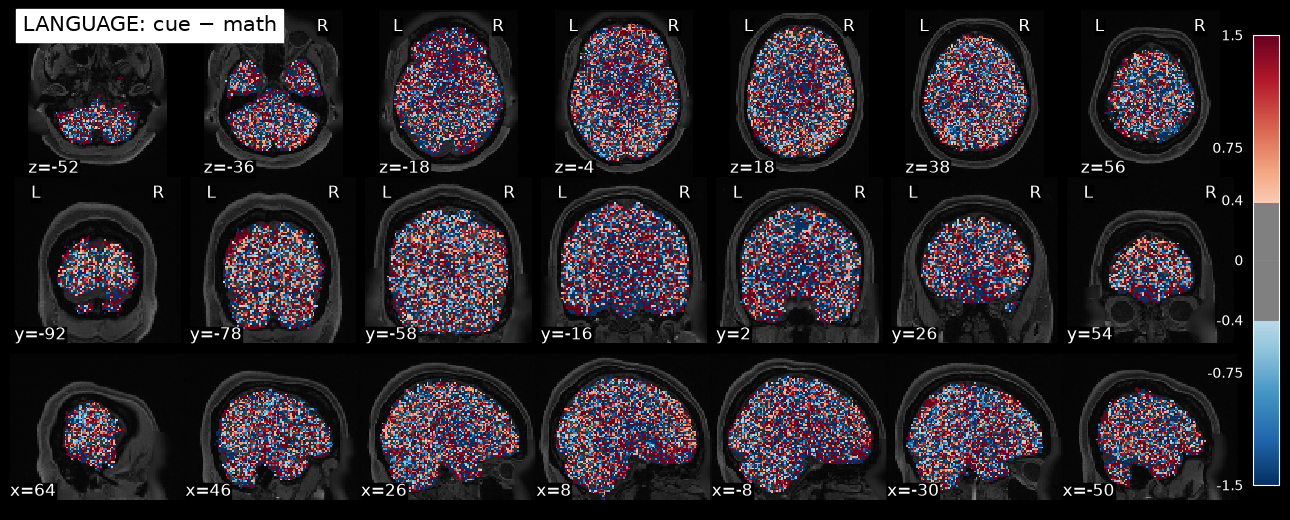

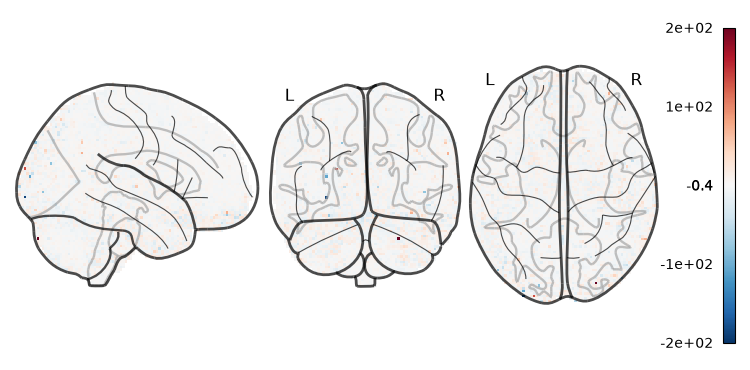

In [225]:
img4 = nib.load(str(run / f"{stem}_hp0_clean_rclean_tclean.nii.gz"))
vol  = img4.get_fdata(dtype=np.float32)                     # (91,109,91,nt), ~1 GB
mean3d = nib.load(str(run / f"{stem}_mean.nii.gz")).get_fdata()

diff3d = vol[..., blocks[COND_A]].mean(-1) - vol[..., blocks[COND_B]].mean(-1)
contrast3d = np.where(mean3d > 0, diff3d / np.maximum(mean3d, 1) * 100, 0)
stat = nib.Nifti1Image(contrast3d.astype(np.float32), img4.affine)

anat = ROOT / "data" / SUBJECT / "MNINonLinear/T1w_restore.2.nii.gz"

plotting.view_img(stat, bg_img=str(anat), threshold=0.4, vmax=1.5,
                  cmap="RdBu_r", title=f"{TASK}: {COND_A} − {COND_B} (%)")

plotting.plot_stat_map(stat, bg_img=str(anat), threshold=0.4, vmax=1.5,
                       display_mode="mosaic", title=f"{TASK}: {COND_A} − {COND_B}")
plotting.plot_glass_brain(stat, threshold=0.4, colorbar=True, plot_abs=False)

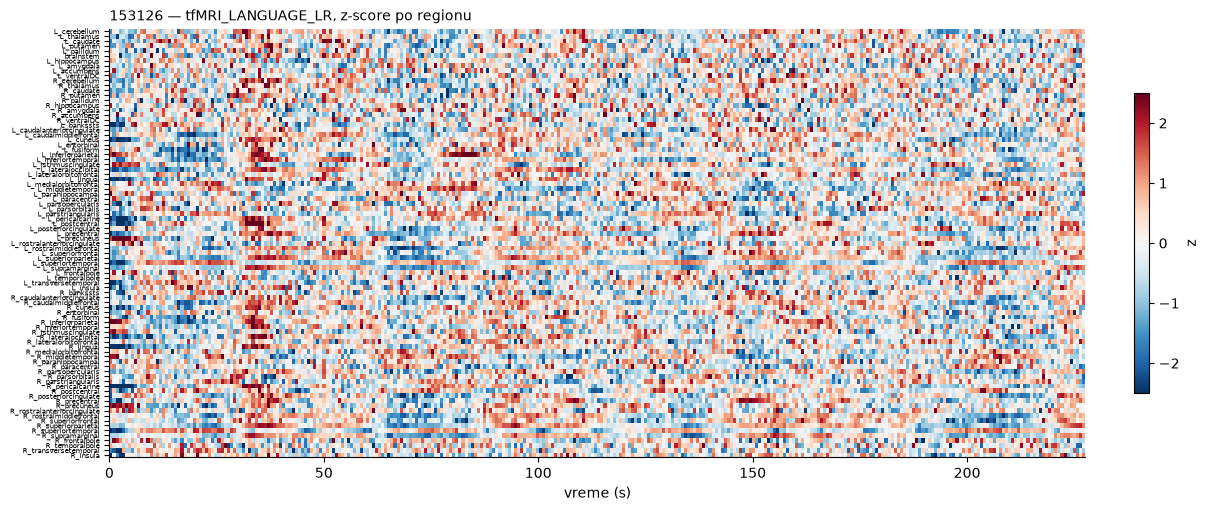

In [226]:
i = np.flatnonzero((subjects == SUBJECT) & (y == TASK) & (encodings == ENC))[0]
Z = runs[i]
Z = ((Z - Z.mean(0)) / np.where(Z.std(0) > 0, Z.std(0), 1)).T      # (87, T)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(Z, aspect="auto", cmap="RdBu_r", vmin=-2.5, vmax=2.5,
               extent=[0, Z.shape[1] * TR, Z.shape[0], 0], interpolation="nearest")
ax.set_xlabel("vreme (s)")
ax.set_yticks(np.arange(len(names)) + 0.5)
ax.set_yticklabels(names, fontsize=5)
ax.grid(False)
for f in blocks[COND_A]:
    ax.axvline(f * TR, color="k", lw=0.3, alpha=0.15)
ax.set_title(f"{SUBJECT} — {stem}, z-score po regionu")
fig.colorbar(im, ax=ax, shrink=0.7, label="z")

Text(0.01, 0.98, '153126 — tfMRI_LANGUAGE_LR')

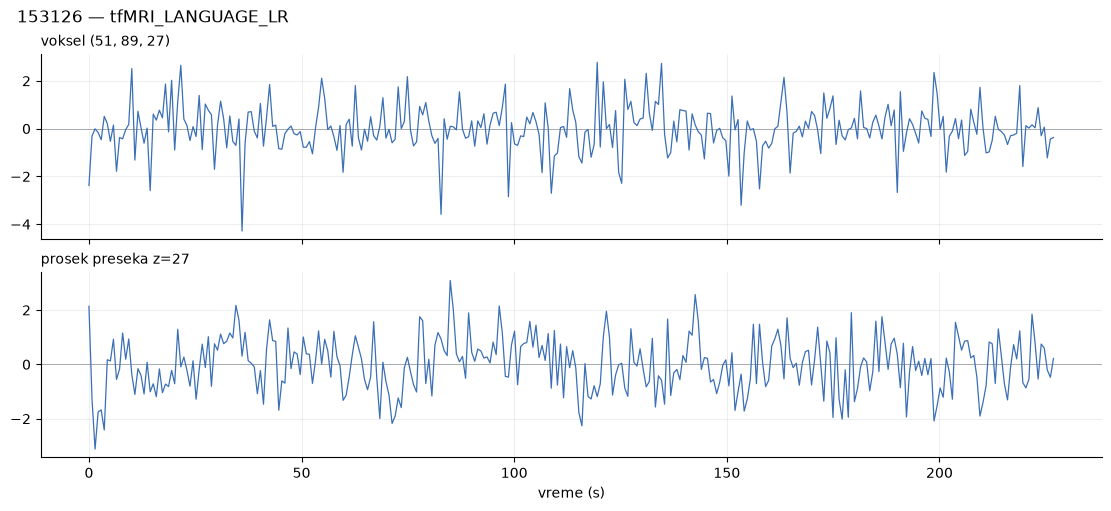

In [218]:
assert stem == f"tfMRI_{TASK}_{ENC}", "ponovo pokreni ćeliju A"

sd = sl.std(axis=-1)
vx, vy = np.unravel_index(np.argmax(np.where(mask, sd, 0)), sd.shape)

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
for ax, sig, title in [(axes[0], sl[vx, vy, :], f"voksel ({vx}, {vy}, {CZ})"),
                       (axes[1], sl[mask].mean(axis=0), f"prosek preseka z={CZ}")]:
    ax.plot(t, (sig - sig.mean()) / sig.std(), lw=0.9, color=ACCENT)
    ax.set_title(title)
    ax.axhline(0, lw=0.6, color=MUTED, zorder=0)
axes[-1].set_xlabel("vreme (s)")
fig.suptitle(f"{SUBJECT} — {stem}", x=0.01, ha="left")

Text(0.01, 0.98, 'Spektar po zadatku — L_precentral (sivo = prosek svih)')

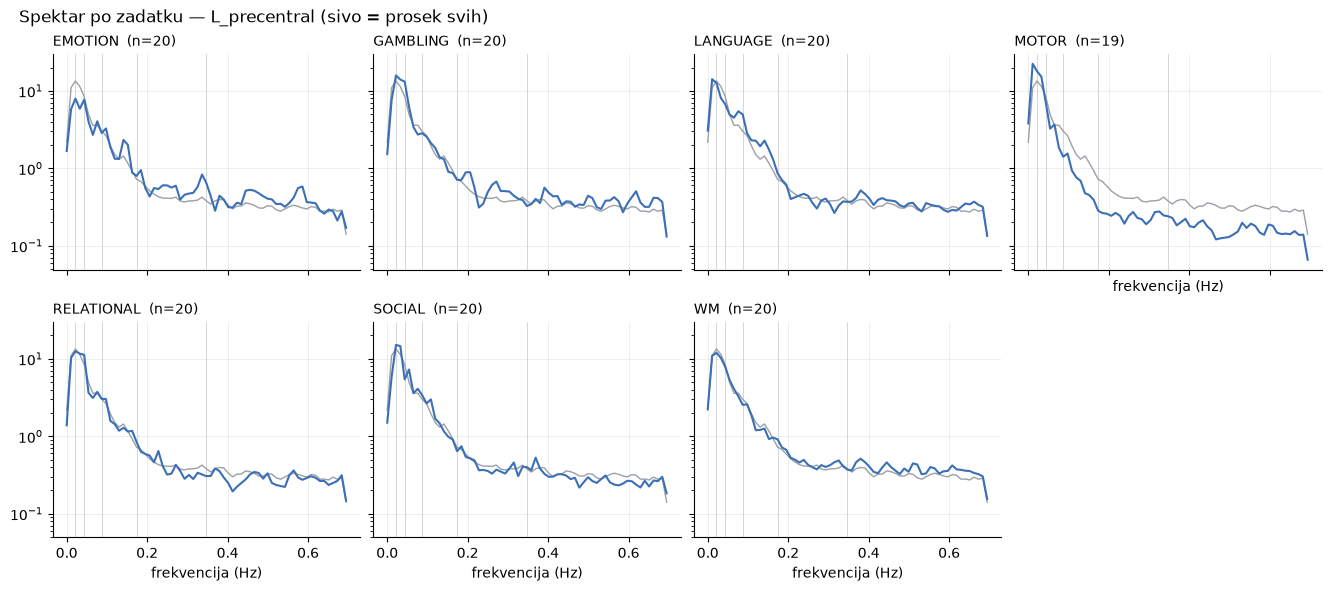

In [222]:
NPERSEG = 128
FS, NYQ = 1 / TR, 1 / (2 * TR)

psd = {}
for task in TASKS:
    acc = []
    for i in np.flatnonzero(y == task):
        sig = runs[i][:, REGION]
        f, p = welch((sig - sig.mean()) / sig.std(), fs=FS, nperseg=NPERSEG)
        acc.append(p)
    psd[task] = np.mean(acc, axis=0)
grand = np.mean(list(psd.values()), axis=0)

NR = -(-len(TASKS) // NCOLS)
fig, axes = plt.subplots(NR, NCOLS, figsize=(3.3 * NCOLS, 2.9 * NR),
                         sharex=True, sharey=True)
for ax, task in zip(axes.flat, TASKS):
    for l in range(1, 6):
        ax.axvline(NYQ / 2 ** l, lw=0.5, color=MUTED, alpha=0.6, zorder=0)
    ax.semilogy(f, grand, lw=1.0, color=MUTED, zorder=1)
    ax.semilogy(f, psd[task], lw=1.5, color=ACCENT, zorder=2)
    ax.set_title(f"{task}  (n={np.sum(y == task)})")
for j, ax in enumerate(axes.flat):
    if j >= len(TASKS):
        ax.set_visible(False)
    elif j + NCOLS >= len(TASKS):
        ax.set_xlabel("frekvencija (Hz)")
fig.suptitle(f"Spektar po zadatku — {REGION_NAME} (sivo = prosek svih)", x=0.01, ha="left")